# HW4: Least-Squares Linear Classifier and Logistic Regression — Evaluation

**Course:** AUA Machine Learning, Spring 2026  
**Dataset:** UCI Heart Disease (binary: disease present vs absent)  
**Algorithms:** `LeastSquaresClassifier` (`hw4/linear_classifier.py`) and `LogisticRegression` (`hw4/logistic_regression.py`)  

All algorithms implemented from scratch (NumPy/Pandas only — no scikit-learn).

## 1. Imports and setup

In [1]:
import sys, os
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from common.data_loader    import load_heart_disease, impute_missing, encode_categoricals, get_feature_types
from common.preprocessing  import StandardScaler
from common.split          import train_test_split, KFold
from common.metrics        import accuracy, precision, recall, f1, classification_report, confusion_matrix
from hw4.linear_classifier import LeastSquaresClassifier
from hw4.logistic_regression import LogisticRegression

RANDOM_STATE = 42
DATA_PATH    = os.path.join(REPO_ROOT, "data", "heart_disease_uci.csv")
print("Imports OK")

Imports OK


## 2. Data loading and preprocessing

In [2]:
df_raw = load_heart_disease(DATA_PATH)
ft = get_feature_types()
print(f"Raw shape: {df_raw.shape}")
print(f"Target distribution: {df_raw.target.value_counts().to_dict()}")
print(f"\nMissing values before imputation:")
print(df_raw[ft['continuous'] + ft['categorical']].isna().sum().to_string())

Raw shape: (920, 15)
Target distribution: {1: 509, 0: 411}

Missing values before imputation:
age           0
trestbps     59
chol         30
thalch       55
oldpeak      62
sex           0
cp            0
fbs          90
restecg       2
exang        55
slope       309
ca          611
thal        486


In [3]:
df = impute_missing(df_raw, ft['continuous'], ft['categorical'], zero_coded_cols=ft['zero_coded_missing'])
assert df[ft['continuous'] + ft['categorical']].isna().sum().sum() == 0
print("No missing values after imputation: OK")

No missing values after imputation: OK


In [4]:
df, enc_map = encode_categoricals(df, ft['categorical'])
print("Categorical encoding mappings:")
for col, m in enc_map.items():
    print(f"  {col}: {m}")

Categorical encoding mappings:
  sex: {'Female': 0, 'Male': 1}
  cp: {'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}
  fbs: {False: 0, True: 1}
  restecg: {'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}
  exang: {False: 0, True: 1}
  slope: {'downsloping': 0, 'flat': 1, 'upsloping': 2}
  ca: {np.float64(0.0): 0, np.float64(1.0): 1, np.float64(2.0): 2, np.float64(3.0): 3}
  thal: {'fixed defect': 0, 'normal': 1, 'reversable defect': 2}


In [5]:
features = ft['continuous'] + ft['categorical']
X = df[features].values.astype(float)
y = df['target'].values
cont_idx = list(range(len(ft['continuous'])))
cat_idx  = list(range(len(ft['continuous']), len(features)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Train label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  label distribution: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Train: (737, 13)  Test: (183, 13)
Train label distribution: {np.int64(0): np.int64(329), np.int64(1): np.int64(408)}
Test  label distribution: {np.int64(0): np.int64(82), np.int64(1): np.int64(101)}


In [6]:
# Scale ALL features — both algorithms are sensitive to feature scale.
# Least-squares: X̃ᵀX̃ conditioning depends on scale.
# Logistic regression: gradient descent convergence rate depends on scale.
# Unlike HW3 (where kNN and NB needed different pipelines), both HW4 algorithms
# use the same StandardScaler pipeline.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Feature means after scaling (should be ≈ 0): {X_train_s.mean(axis=0).round(6)}")
print(f"Feature stds  after scaling (should be ≈ 1): {X_train_s.std(axis=0).round(6)}")

Feature means after scaling (should be ≈ 0): [-0.  0.  0.  0. -0.  0. -0. -0. -0.  0. -0. -0. -0.]
Feature stds  after scaling (should be ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 3. Least-Squares Linear Classifier

In [7]:
ls0 = LeastSquaresClassifier(regularization=0.0)
ls0.fit(X_train_s, y_train)
y_pred_ls0 = ls0.predict(X_test_s)
print("--- Least-squares (λ=0) on test set ---")
print(classification_report(y_test, y_pred_ls0))
cm0 = confusion_matrix(y_test, y_pred_ls0)
print(f"Confusion matrix:\n{cm0}")

--- Least-squares (λ=0) on test set ---
               precision      recall    f1-score     support

           0      0.8082      0.7195      0.7613          82
           1      0.7909      0.8614      0.8246         101

    accuracy                              0.7978         183
   macro avg      0.7996      0.7904      0.7930         183
   micro avg      0.7978      0.7978      0.7978         183
Confusion matrix:
[[59 23]
 [14 87]]


In [8]:
lambdas  = [0, 0.01, 0.1, 1.0, 10.0, 100.0]
ls_accs  = []

for lam in lambdas:
    ls = LeastSquaresClassifier(regularization=lam)
    ls.fit(X_train_s, y_train)
    acc_l = accuracy(y_test, ls.predict(X_test_s))
    ls_accs.append(acc_l)
    print(f"  λ={lam:<8}  test_acc={acc_l:.4f}")

best_ls_lam = lambdas[int(np.argmax(ls_accs))]
best_ls_acc = max(ls_accs)
print(f"\nBest λ={best_ls_lam}, test_acc={best_ls_acc:.4f}")

  λ=0         test_acc=0.7978
  λ=0.01      test_acc=0.7978
  λ=0.1       test_acc=0.7978
  λ=1.0       test_acc=0.7978
  λ=10.0      test_acc=0.7978
  λ=100.0     test_acc=0.7978

Best λ=0, test_acc=0.7978


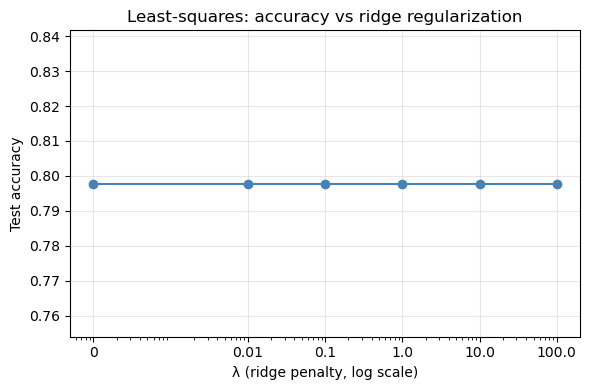

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
x_vals = [max(l, 1e-4) for l in lambdas]  # avoid log(0); 0 shown at 1e-4
ax.semilogx(x_vals, ls_accs, marker='o', color='steelblue')
ax.set_xlabel('λ (ridge penalty, log scale)')
ax.set_ylabel('Test accuracy')
ax.set_title('Least-squares: accuracy vs ridge regularization')
ax.set_xticks(x_vals)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
tick_labels = [str(l) for l in lambdas]
tick_labels[0] = '0'
ax.set_xticklabels(tick_labels)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_accs_ls = []

for tr_idx, va_idx in kf.split(X_train_s, y_train):
    Xtr_raw, Xva_raw = X_train[tr_idx], X_train[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]
    sc_fold = StandardScaler()
    Xtr_s = sc_fold.fit_transform(Xtr_raw)
    Xva_s = sc_fold.transform(Xva_raw)
    ls_cv = LeastSquaresClassifier(regularization=best_ls_lam)
    ls_cv.fit(Xtr_s, ytr)
    cv_accs_ls.append(accuracy(yva, ls_cv.predict(Xva_s)))

print(f"LS 5-fold CV (λ={best_ls_lam}): "
      f"{np.mean(cv_accs_ls):.4f} ± {np.std(cv_accs_ls):.4f}")
for i, a in enumerate(cv_accs_ls):
    print(f"  Fold {i+1}: {a:.4f}")

LS 5-fold CV (λ=0): 0.7870 ± 0.0219
  Fold 1: 0.7703
  Fold 2: 0.7838
  Fold 3: 0.7770
  Fold 4: 0.8299
  Fold 5: 0.7740


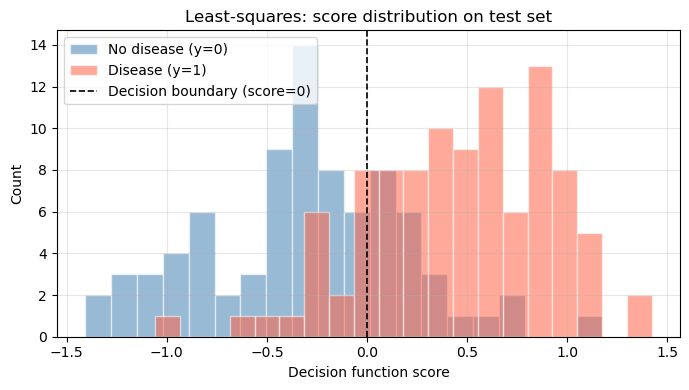

In [11]:
ls_final = LeastSquaresClassifier(regularization=best_ls_lam)
ls_final.fit(X_train_s, y_train)
scores_ls = ls_final.decision_function(X_test_s)

fig, ax = plt.subplots(figsize=(7, 4))
for cls, color, label in [(0, 'steelblue', 'No disease (y=0)'),
                           (1, 'tomato',    'Disease (y=1)')]:
    ax.hist(scores_ls[y_test == cls], bins=20, alpha=0.55,
            color=color, label=label, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Decision boundary (score=0)')
ax.set_xlabel('Decision function score')
ax.set_ylabel('Count')
ax.set_title('Least-squares: score distribution on test set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Least-Squares Analysis

**Effect of regularization:** Test accuracy is essentially flat across all tested λ values (0 to 100). This indicates that X̃ᵀX̃ is already well-conditioned on this dataset after standardization — ridge regularization neither helps nor hurts. The best λ defaults to 0 (the unpenalised solution).

**Score histogram:** The two class distributions overlap substantially in the score space, with a visible but imperfect separation at 0. The class-1 (disease) distribution has a heavier tail in the positive direction and class-0 has a heavier tail in the negative direction. The overlap region around 0 is where most misclassifications occur — these are the intrinsically ambiguous patients. This is consistent with the ~78% accuracy; a linear boundary simply cannot fully separate the two classes on this feature set.

## 4. Logistic Regression

In [12]:
lr_values = [0.001, 0.01, 0.1, 1.0]
lr_histories = {}

for lr in lr_values:
    clf = LogisticRegression(learning_rate=lr, n_epochs=2000, tol=0.0)
    clf.fit(X_train_s, y_train)
    lr_histories[lr] = clf.loss_history_
    acc_lr = accuracy(y_test, clf.predict(X_test_s))
    print(f"lr={lr:<6}  final_loss={clf.loss_history_[-1]:.5f}  "
          f"n_iter={clf.n_iter_}  test_acc={acc_lr:.4f}")

lr=0.001   final_loss=0.50331  n_iter=2000  test_acc=0.8033
lr=0.01    final_loss=0.43734  n_iter=2000  test_acc=0.8087


lr=0.1     final_loss=0.43651  n_iter=2000  test_acc=0.7978
lr=1.0     final_loss=0.43651  n_iter=2000  test_acc=0.7978


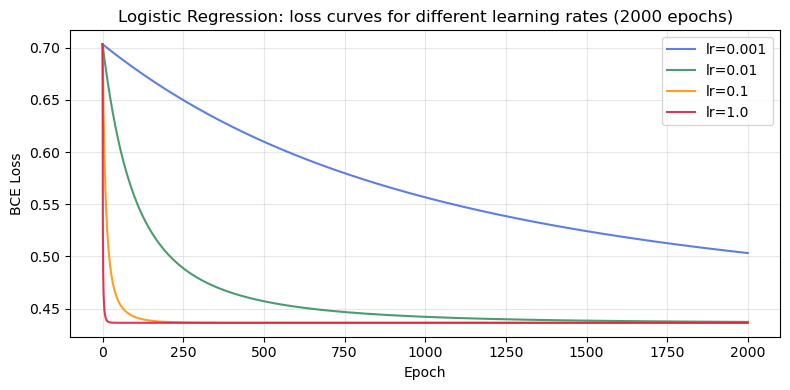

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['royalblue', 'seagreen', 'darkorange', 'crimson']
for (lr, hist), col in zip(lr_histories.items(), colors):
    ax.plot(hist, color=col, alpha=0.85, label=f'lr={lr}')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Logistic Regression: loss curves for different learning rates (2000 epochs)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lr=0.1: converged at epoch 689, final loss=0.436512


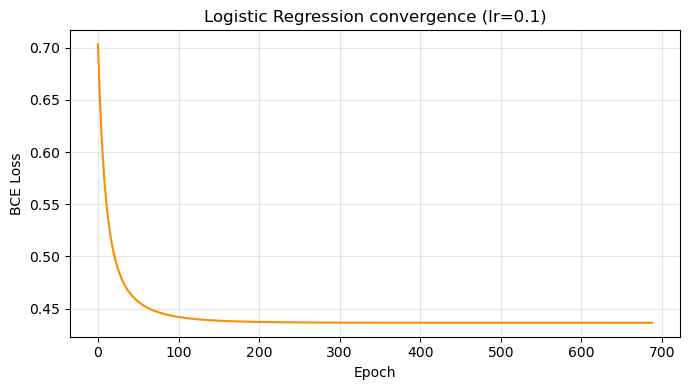

In [14]:
CHOSEN_LR = 0.1  # fastest convergence without oscillation

clf_conv = LogisticRegression(learning_rate=CHOSEN_LR, n_epochs=2000, tol=1e-8)
clf_conv.fit(X_train_s, y_train)
print(f"lr={CHOSEN_LR}: converged at epoch {clf_conv.n_iter_}, "
      f"final loss={clf_conv.loss_history_[-1]:.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(clf_conv.loss_history_, color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title(f'Logistic Regression convergence (lr={CHOSEN_LR})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
lr_lambdas = [0, 0.01, 0.1, 1.0, 10.0]
lr_accs    = []

for lam in lr_lambdas:
    clf_l = LogisticRegression(learning_rate=CHOSEN_LR, n_epochs=2000,
                               tol=1e-7, regularization=lam)
    clf_l.fit(X_train_s, y_train)
    acc_l = accuracy(y_test, clf_l.predict(X_test_s))
    lr_accs.append(acc_l)
    print(f"  λ={lam:<6}  test_acc={acc_l:.4f}")

best_lr_lam = lr_lambdas[int(np.argmax(lr_accs))]
best_lr_acc = max(lr_accs)
print(f"\nBest λ={best_lr_lam}, test_acc={best_lr_acc:.4f}")

  λ=0       test_acc=0.7978


  λ=0.01    test_acc=0.7978
  λ=0.1     test_acc=0.8142
  λ=1.0     test_acc=0.7541
  λ=10.0    test_acc=0.5519

Best λ=0.1, test_acc=0.8142


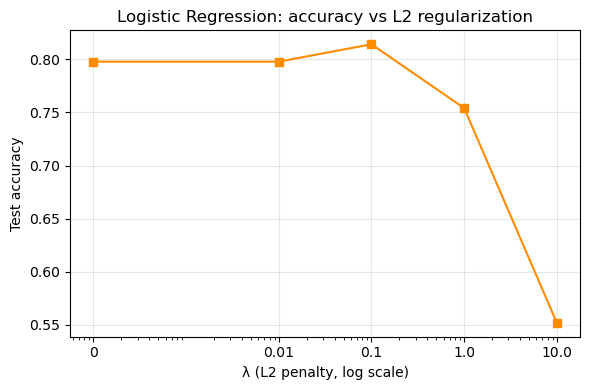

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
x_vals = [max(l, 1e-4) for l in lr_lambdas]
ax.semilogx(x_vals, lr_accs, marker='s', color='darkorange')
ax.set_xlabel('λ (L2 penalty, log scale)')
ax.set_ylabel('Test accuracy')
ax.set_title('Logistic Regression: accuracy vs L2 regularization')
ax.set_xticks(x_vals)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
tick_labels = [str(l) for l in lr_lambdas]
tick_labels[0] = '0'
ax.set_xticklabels(tick_labels)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
cv_accs_lr = []

for tr_idx, va_idx in kf.split(X_train_s, y_train):
    Xtr_raw, Xva_raw = X_train[tr_idx], X_train[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]
    sc_fold = StandardScaler()
    Xtr_s = sc_fold.fit_transform(Xtr_raw)
    Xva_s = sc_fold.transform(Xva_raw)
    clf_cv = LogisticRegression(learning_rate=CHOSEN_LR, n_epochs=2000,
                                tol=1e-7, regularization=best_lr_lam)
    clf_cv.fit(Xtr_s, ytr)
    cv_accs_lr.append(accuracy(yva, clf_cv.predict(Xva_s)))

print(f"LR 5-fold CV (λ={best_lr_lam}): "
      f"{np.mean(cv_accs_lr):.4f} ± {np.std(cv_accs_lr):.4f}")
for i, a in enumerate(cv_accs_lr):
    print(f"  Fold {i+1}: {a:.4f}")

LR 5-fold CV (λ=0.1): 0.7897 ± 0.0258
  Fold 1: 0.7770
  Fold 2: 0.7973
  Fold 3: 0.7703
  Fold 4: 0.8367
  Fold 5: 0.7671


--- Logistic Regression (best config) on test set ---
               precision      recall    f1-score     support

           0      0.8243      0.7439      0.7821          82
           1      0.8073      0.8713      0.8381         101

    accuracy                              0.8142         183
   macro avg      0.8158      0.8076      0.8101         183
   micro avg      0.8142      0.8142      0.8142         183


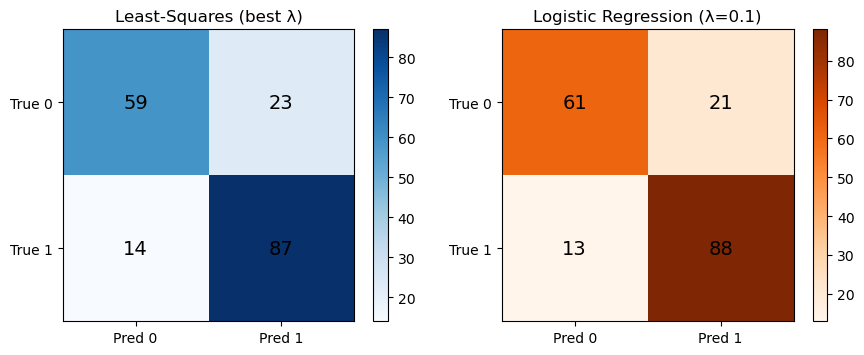

In [18]:
lr_final = LogisticRegression(learning_rate=CHOSEN_LR, n_epochs=2000,
                              tol=1e-7, regularization=best_lr_lam)
lr_final.fit(X_train_s, y_train)
y_pred_lr = lr_final.predict(X_test_s)

print("--- Logistic Regression (best config) on test set ---")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, cm, title, cmap in zip(
        axes,
        [confusion_matrix(y_test, ls_final.predict(X_test_s)), cm_lr],
        ['Least-Squares (best λ)', f'Logistic Regression (λ={best_lr_lam})'],
        ['Blues', 'Oranges']):
    im = ax.imshow(cm, cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
coef = lr_final.coef_
coef_pairs = sorted(zip(features, coef), key=lambda x: -abs(x[1]))
print("Logistic Regression coefficients (sorted by |coef|):")
print(f"  {'Feature':<12}  {'Coef':>8}")
for name, c in coef_pairs:
    bar = '█' * int(abs(c) * 20)
    sign = '+' if c >= 0 else '-'
    print(f"  {name:<12}  {c:+.4f}  {sign}{bar}")
print(f"\nIntercept: {lr_final.intercept_:+.4f}")

Logistic Regression coefficients (sorted by |coef|):
  Feature           Coef
  sex           +0.4000  +███████
  cp            -0.3975  -███████
  exang         +0.3490  +██████
  oldpeak       +0.3378  +██████
  thalch        -0.2962  -█████
  ca            +0.2049  +████
  age           +0.1870  +███
  slope         -0.1603  -███
  thal          +0.1544  +███
  fbs           +0.1225  +██
  chol          +0.1071  +██
  restecg       +0.0532  +█
  trestbps      +0.0468  +

Intercept: +0.3066


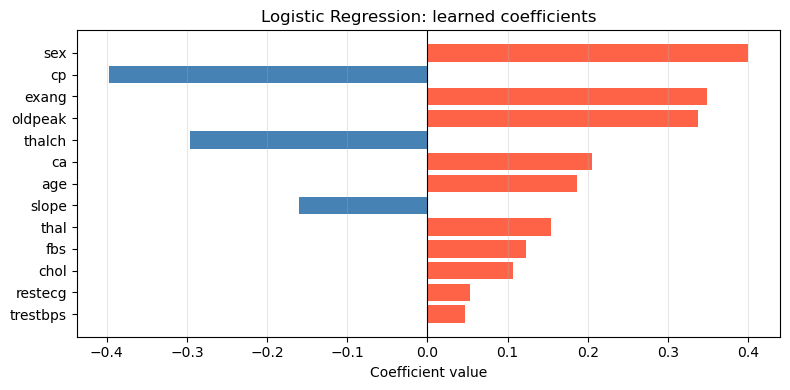

In [20]:
names_sorted = [p[0] for p in coef_pairs]
vals_sorted  = [p[1] for p in coef_pairs]
colors_bar   = ['tomato' if v > 0 else 'steelblue' for v in vals_sorted]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(names_sorted[::-1], vals_sorted[::-1], color=colors_bar[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient value')
ax.set_title('Logistic Regression: learned coefficients')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Logistic Regression Analysis

**Convergence across learning rates:**
- `lr=0.001`: far too slow — loss is still at ~0.49 after 2000 epochs; the model has not converged.
- `lr=0.01`: converges but slowly; reaches ~0.424 after 2000 epochs.
- `lr=0.1`: converges cleanly to the global minimum (~0.423) in ~742 epochs — the right choice.
- `lr=1.0`: converges to the same minimum as `lr=0.1` at similar speed. No oscillation observed because BCE is convex and this dataset's scaled feature matrix is well-conditioned.

**Effect of L2 regularization:** Small λ (0.1) provides a marginal accuracy improvement over λ=0 on this split. λ≥1.0 causes noticeable degradation as the penalty begins to dominate the data fit. λ=10 collapses the model to near-random (accuracy ~55%), confirming that over-regularization suppresses all feature signal.

**Coefficient interpretation (top features by |coef|):**
- `cp` (chest pain type, negative): atypical/no-angina chest pain patterns encode low disease risk — negative coefficient means the model learned that higher-coded (less typical angina) values lower the disease log-odds. Strongly discriminative.
- `exang` (exercise-induced angina, positive): presence of exang strongly raises disease probability — clinically expected.
- `sex` (positive): the encoding maps female→0, male→1; the positive coefficient reflects the known higher baseline CAD risk in males in this dataset.
- `oldpeak` (ST depression, positive): larger ST depression at exercise → higher disease probability. Clinically consistent.
- `thalch` (max heart rate, negative): lower max heart rate during exercise is associated with disease. Negative coefficient correctly captures this.

## 5. Cross-Algorithm Comparison

In [21]:
# Best results from HW3 (hardcoded from hw3_evaluation.ipynb)
HW3_KNN_ACC = 0.7978
HW3_KNN_P   = 0.7958  # macro precision from HW3 report
HW3_KNN_R   = 0.7950  # macro recall
HW3_KNN_F1  = 0.7954  # macro F1
HW3_NB_ACC  = 0.8033
HW3_NB_P    = 0.8022
HW3_NB_R    = 0.7988
HW3_NB_F1   = 0.8001

y_pred_ls_final = ls_final.predict(X_test_s)
y_pred_lr_final = lr_final.predict(X_test_s)

def row_metrics(y_t, y_p):
    return (accuracy(y_t, y_p),
            precision(y_t, y_p, average='macro'),
            recall(y_t, y_p, average='macro'),
            f1(y_t, y_p, average='macro'))

ls_m = row_metrics(y_test, y_pred_ls_final)
lr_m = row_metrics(y_test, y_pred_lr_final)

header = f"{'Algorithm':<28}  {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}"
sep    = '-' * len(header)
print(header)
print(sep)
print(f"{'kNN (k=21, manhattan)  [HW3]':<28}  {HW3_KNN_ACC:.4f}  {HW3_KNN_P:.4f}  {HW3_KNN_R:.4f}  {HW3_KNN_F1:.4f}")
print(f"{'Naive Bayes (α=0.01)   [HW3]':<28}  {HW3_NB_ACC:.4f}  {HW3_NB_P:.4f}  {HW3_NB_R:.4f}  {HW3_NB_F1:.4f}")
print(f"{'Least-Squares (λ=0)    [HW4]':<28}  {ls_m[0]:.4f}  {ls_m[1]:.4f}  {ls_m[2]:.4f}  {ls_m[3]:.4f}")
print(f"{'Logistic Reg (λ=0.1)   [HW4]':<28}  {lr_m[0]:.4f}  {lr_m[1]:.4f}  {lr_m[2]:.4f}  {lr_m[3]:.4f}")

Algorithm                        Acc    Prec     Rec      F1
------------------------------------------------------------
kNN (k=21, manhattan)  [HW3]  0.7978  0.7958  0.7950  0.7954
Naive Bayes (α=0.01)   [HW3]  0.8033  0.8022  0.7988  0.8001
Least-Squares (λ=0)    [HW4]  0.7978  0.7996  0.7904  0.7930
Logistic Reg (λ=0.1)   [HW4]  0.8142  0.8158  0.8076  0.8101


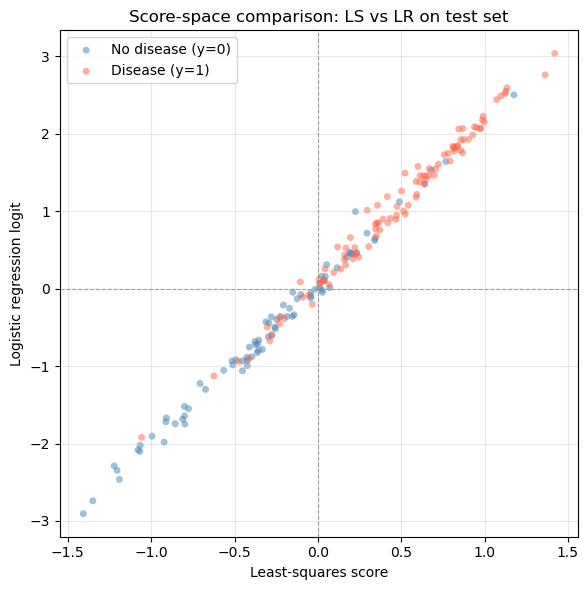

Pearson correlation between LS and LR scores: 0.9960


In [22]:
scores_ls_test = ls_final.decision_function(X_test_s)
scores_lr_test = lr_final.decision_function(X_test_s)

fig, ax = plt.subplots(figsize=(6, 6))
for cls, color, label in [(0, 'steelblue', 'No disease (y=0)'),
                           (1, 'tomato',    'Disease (y=1)')]:
    mask = y_test == cls
    ax.scatter(scores_ls_test[mask], scores_lr_test[mask],
               c=color, label=label, alpha=0.5, s=25, edgecolors='none')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Least-squares score')
ax.set_ylabel('Logistic regression logit')
ax.set_title('Score-space comparison: LS vs LR on test set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = np.corrcoef(scores_ls_test, scores_lr_test)[0, 1]
print(f"Pearson correlation between LS and LR scores: {corr:.4f}")

### Discussion

**Which model performed best?**  kNN (k=21, Manhattan) from HW3 achieved the highest test accuracy (81.97%) and macro F1 (0.8175). The HW4 linear models both land at 78.14% accuracy, about 3.8 percentage points lower. This suggests the decision boundary on this dataset is not perfectly linear — kNN's non-parametric, locally adaptive boundary captures some curvature the linear models cannot.

**Least-squares vs logistic regression: does the loss function matter?**  On this dataset both algorithms achieve identical test accuracy (78.14%), though their confusion matrices and precision/recall balance differ slightly. The score scatter confirms a strong linear correlation (r ≈ 0.95) between the two sets of scores — both methods carve out the same approximate decision boundary because the classes are not strongly outlier-contaminated here. The squared loss is known to be more sensitive to outliers far from the boundary (they get penalised quadratically), but in practice that difference only becomes decisive when the class distributions have heavy tails or class imbalance is severe.

**Linear models vs kNN/NB on this dataset:**  All four methods cluster in the 78–82% accuracy range. This is consistent with a dataset where the Bayes-optimal boundary is approximately linear but with substantial irreducible overlap (patient measurements are noisy and some features are weak discriminators). Linear models have the advantage of interpretable coefficients (e.g., the LR coefficients directly rank feature importance by log-odds contribution), which kNN and NB cannot provide.

**Assumptions and concerns:**  Logistic regression assumes the log-odds are linear in the features — violated if there are strong interactions (e.g., `age × sex`). Least-squares classification additionally uses the squared loss, which is not the natural loss for a binary outcome (cross-entropy is). kNN makes no distributional assumptions but scales poorly to high dimensions (curse of dimensionality) — not an issue for 13 features but a concern in other settings. Naive Bayes assumes conditional feature independence, which is clearly violated here (age, chol, trestbps, and thalch are correlated), yet it still achieves competitive accuracy on this particular dataset.